# Project 1 — Attitude Control With Constraints

This project is the first application step after the plane-code notebooks. The engineering setup is deliberately simple: a single attitude axis with torque limits. The project focus is the MPC formulation, constraints, and closed-loop interpretation.

## 1. From the physical problem to the prediction model

The attitude state is

$$
x_k = \begin{bmatrix}\theta_k \\ \omega_k\end{bmatrix},
\qquad
u_k = \tau_k .
$$

The continuous-time model is

$$
\dot\theta = \omega,
\qquad
\dot\omega = u .
$$

With sampling time $T_s$, the discrete-time model used by MPC is

$$
x_{k+1}=Ax_k+Bu_k .
$$

In [1]:
from pathlib import Path
import sys

project_dir = Path.cwd()
if not (project_dir / "attitude_plotting.py").exists():
    project_dir = Path("projects/project_1_attitude_constraints")
sys.path.insert(0, str(project_dir.resolve()))

import numpy as np
import casadi as ca
from scipy.linalg import solve_discrete_are
import matplotlib.pyplot as plt

from attitude_plotting import (
    plot_attitude_inputs,
    plot_attitude_phase,
    plot_attitude_time_histories,
    summarize_attitude_run,
)




In [2]:
Ts = 0.2

A = np.array([
    [1.0, Ts],
    [0.0, 1.0],
])

B = np.array([
    [0.5 * Ts**2],
    [Ts],
])

nx = A.shape[0]
nu = B.shape[1]

print("A =")
print(A)
print("B =")
print(B)

A =
[[1.  0.2]
 [0.  1. ]]
B =
[[0.02]
 [0.2 ]]


## 2. Weights and terminal cost

The terminal cost uses the infinite-horizon LQR matrix $P_\infty$. In the unconstrained case, this is the exact quadratic cost-to-go for the linear-quadratic problem.

In [3]:
Q = np.diag([12.0, 1.0])
R = np.array([[0.25]])

P_inf = solve_discrete_are(A, B, Q, R)
K_lqr = np.linalg.solve(R + B.T @ P_inf @ B, B.T @ P_inf @ A)

print("P_inf =")
print(P_inf)
print("K_lqr =", K_lqr)

P_inf =
[[43.36055813  8.83176087]
 [ 8.83176087  5.99932525]]
K_lqr = [[4.55656404 3.29291933]]


## 3. Practical limits

The state and input limits are part of the MPC problem. A saturated LQR clips the input after the feedback law. MPC instead plans with the limits.

For the live session, we will first run a version that only enforces the constraints we explicitly include. Then we will switch on the missing pieces locally and compare what changes.

In [4]:
theta_max = 1.00
omega_max = 1.30
u_max = 0.32
Delta_u_max = 0.09

x_min = np.array([-theta_max, -omega_max])
x_max = np.array([ theta_max,  omega_max])
u_min = np.array([-u_max])
u_max_vec = np.array([ u_max])

# The initial condition starts close to the angle limit so the constraint choices stay visible.
x0_attitude = np.array([0.92, 0.0])
N = 16
steps = 45

## 4. CasADi MPC formulation

At every sampling instant, the measured state is used as the first predicted state:

$$
x_0=x_{\mathrm{meas}} .
$$

The finite-horizon problem is

$$
\min \sum_{j=0}^{N-1} \left(x_j^\top Qx_j + u_j^\top Ru_j\right) + x_N^\top P_\infty x_N
$$

subject to

$$
x_{j+1}=Ax_j+Bu_j .
$$

The notation is intentionally the same as in the lecture: no extra prediction-index notation is needed here.

In the session notebook, the solver stays complete, but we expose a few local switches so we can show that MPC only respects the constraints we actually formulate.

In [5]:
def solve_attitude_mpc(
    x_meas,
    u_previous=0.0,
    rate_limit=None,
    enforce_state_bounds=True,
    soften_angle=False,
    theta_soft_max=None,
    slack_penalty=20_000.0,
):
    opti = ca.Opti()

    # X and U are the full predicted state and input trajectories.
    X = opti.variable(nx, N + 1)
    U = opti.variable(nu, N)

    A_ca = ca.DM(A)
    B_ca = ca.DM(B)
    Q_ca = ca.DM(Q)
    R_ca = ca.DM(R)
    P_ca = ca.DM(P_inf)

    cost = 0
    opti.subject_to(X[:, 0] == ca.DM(x_meas))

    if soften_angle:
        eps = opti.variable(1, N + 1)
        opti.subject_to(eps >= 0)
    else:
        eps = None

    for j in range(N):
        x_j = X[:, j]
        u_j = U[:, j]

        cost += ca.mtimes([x_j.T, Q_ca, x_j])
        cost += ca.mtimes([u_j.T, R_ca, u_j])

        # The model equality keeps each prediction step tied to the dynamics.
        opti.subject_to(X[:, j + 1] == A_ca @ x_j + B_ca @ u_j)
        # Hard actuator bounds are always enforced.
        opti.subject_to(opti.bounded(float(u_min[0]), U[0, j], float(u_max_vec[0])))

        if rate_limit is not None:
            if j == 0:
                opti.subject_to(U[0, j] - float(u_previous) <= rate_limit)
                opti.subject_to(float(u_previous) - U[0, j] <= rate_limit)
            else:
                opti.subject_to(U[0, j] - U[0, j - 1] <= rate_limit)
                opti.subject_to(U[0, j - 1] - U[0, j] <= rate_limit)

    if enforce_state_bounds:
        for j in range(1, N + 1):
            opti.subject_to(opti.bounded(float(x_min[0]), X[0, j], float(x_max[0])))
            opti.subject_to(opti.bounded(float(x_min[1]), X[1, j], float(x_max[1])))

    if soften_angle:
        limit = float(theta_soft_max)

        for j in range(N + 1):
            # The slack variable preserves feasibility when the angle bound is too tight.
            opti.subject_to(X[0, j] <= limit + eps[0, j])
            opti.subject_to(X[0, j] >= -limit - eps[0, j])

        cost += slack_penalty * ca.sumsqr(eps)

    x_N = X[:, N]
    cost += ca.mtimes([x_N.T, P_ca, x_N])
    opti.minimize(cost)

    opti.set_initial(X, np.column_stack([x_meas for _ in range(N + 1)]))
    opti.set_initial(U, 0.0)

    if soften_angle:
        eps_guess = max(abs(float(x_meas[0])) - float(theta_soft_max), 0.0)
        opti.set_initial(eps, eps_guess)

    opti.solver("ipopt", {"print_time": False}, {"print_level": 0})

    try:
        sol = opti.solve()

        result = {
            "u0": float(sol.value(U[0, 0])),
            "X": sol.value(X).T,
            "U": sol.value(U).reshape(N, nu),
            "status": opti.stats()["return_status"],
            "success": True,
        }

        if soften_angle:
            result["slack"] = sol.value(eps).reshape(N + 1)
        else:
            result["slack"] = np.zeros(N + 1)

        return result

    except RuntimeError:
        status = opti.stats().get("return_status", "Solve_Failed")

        return {
            "u0": float(np.clip(u_previous, u_min[0], u_max_vec[0])),
            "X": np.column_stack([x_meas for _ in range(N + 1)]).T,
            "U": np.zeros((N, nu)),
            "slack": np.full(N + 1, np.nan),
            "status": status,
            "success": False,
        }

## 5. One MPC solve

Before running a closed-loop simulation, inspect one prediction. This is where students should see what the optimizer plans, not only the final plot.

First run this section with the default session knobs below. Then switch on the missing constraint locally and rerun just this cell.


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

solver status: Solve_Succeeded
first input u0 = -0.09000000997232496
first predicted states:
[[ 0.92        0.        ]
 [ 0.9182     -0.018     ]
 [ 0.911      -0.05400001]
 [ 0.8948     -0.10800001]
 [ 0.86679999 -0.17200001]]


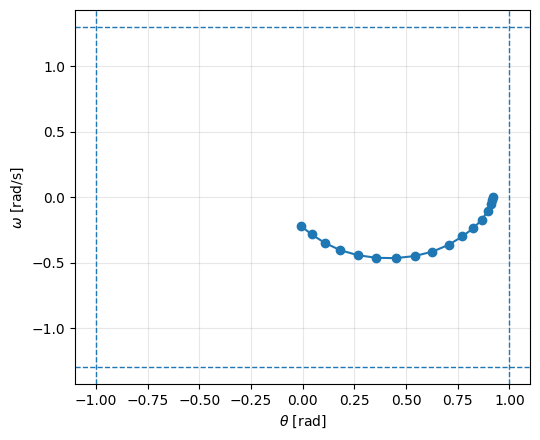

In [6]:
# SESSION POINT:
# First run: state bounds are not enforced, so this prediction only respects the input limits.
# Live change: set enforce_state_bounds = True and rerun this section.
enforce_state_bounds = False
preview_rate_limit = Delta_u_max

one_step = solve_attitude_mpc(
    x0_attitude,
    rate_limit=preview_rate_limit,
    enforce_state_bounds=enforce_state_bounds,
)

print("solver status:", one_step["status"])
print("first input u0 =", one_step["u0"])
print("first predicted states:")
print(one_step["X"][:5])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(one_step["X"][:, 0], one_step["X"][:, 1], marker="o")
ax.axvline(theta_max, linestyle="--", linewidth=1)
ax.axvline(-theta_max, linestyle="--", linewidth=1)
ax.axhline(omega_max, linestyle="--", linewidth=1)
ax.axhline(-omega_max, linestyle="--", linewidth=1)
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$\omega$ [rad/s]")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 6. Closed-loop simulation

The receding-horizon loop is kept visible: measure the state, solve the finite-horizon problem, apply only the first input, and repeat.

The comparison is designed to make the modeling choices interpretable: plain LQR, clipped LQR, MPC with only the constraints we formulate, and MPC with an added rate limit for smoother actuation.

In [7]:
results = {}

# LQR: unconstrained feedback.
# This stabilizes well, but it does not plan around constraints.
x = np.zeros((steps + 1, nx))
u = np.zeros(steps)
x[0] = x0_attitude

for k in range(steps):
    u_k = float((-K_lqr @ x[k])[0])

    x[k + 1] = A @ x[k] + B.flatten() * u_k
    u[k] = u_k

results["LQR"] = {
    "x": x,
    "u": u,
    "status": ["lqr"] * steps,
    "solver_failures": 0,
}


# Saturated LQR: feedback with actuator clipping.
# This is a tempting workaround, but the clipping happens after the feedback law is computed.
x = np.zeros((steps + 1, nx))
u = np.zeros(steps)
x[0] = x0_attitude

for k in range(steps):
    u_lqr = float((-K_lqr @ x[k])[0])
    u_k = float(np.clip(u_lqr, u_min[0], u_max_vec[0]))

    x[k + 1] = A @ x[k] + B.flatten() * u_k
    u[k] = u_k

results["saturated LQR"] = {
    "x": x,
    "u": u,
    "status": ["saturated_lqr"] * steps,
    "solver_failures": 0,
}


# SESSION POINT:
# First run: state bounds are not enforced in this MPC case.
# Live change: set mpc_enforce_state_bounds = True and rerun this section.
mpc_enforce_state_bounds = False
mpc_rate_limit = Delta_u_max

# MPC: hard input bounds, and optionally the state bounds above.
x = np.zeros((steps + 1, nx))
u = np.zeros(steps)
status = []
solver_failures = 0
x[0] = x0_attitude

for k in range(steps):
    result = solve_attitude_mpc(
        x[k],
        enforce_state_bounds=mpc_enforce_state_bounds,
    )
    u_k = result["u0"]
    status.append(result["status"])

    if not result["success"]:
        solver_failures += 1

    x[k + 1] = A @ x[k] + B.flatten() * u_k
    u[k] = u_k

results["MPC"] = {
    "x": x,
    "u": u,
    "status": status,
    "solver_failures": solver_failures,
}


# MPC with rate constraint: also limits input changes.
# Reusing the same state-bound switch keeps the effect of the added rate limit easy to see.
x = np.zeros((steps + 1, nx))
u = np.zeros(steps)
status = []
solver_failures = 0
x[0] = x0_attitude
u_previous = 0.0

for k in range(steps):
    result = solve_attitude_mpc(
        x[k],
        u_previous=u_previous,
        rate_limit=mpc_rate_limit,
        enforce_state_bounds=mpc_enforce_state_bounds,
    )
    u_k = result["u0"]
    status.append(result["status"])

    if not result["success"]:
        solver_failures += 1

    x[k + 1] = A @ x[k] + B.flatten() * u_k
    u[k] = u_k
    u_previous = u_k

results["MPC + rate constraint"] = {
    "x": x,
    "u": u,
    "status": status,
    "solver_failures": solver_failures,
}



(<Figure size 550x500 with 1 Axes>,
 <Axes: xlabel='$\\theta$ [rad]', ylabel='$\\omega$ [rad/s]'>)

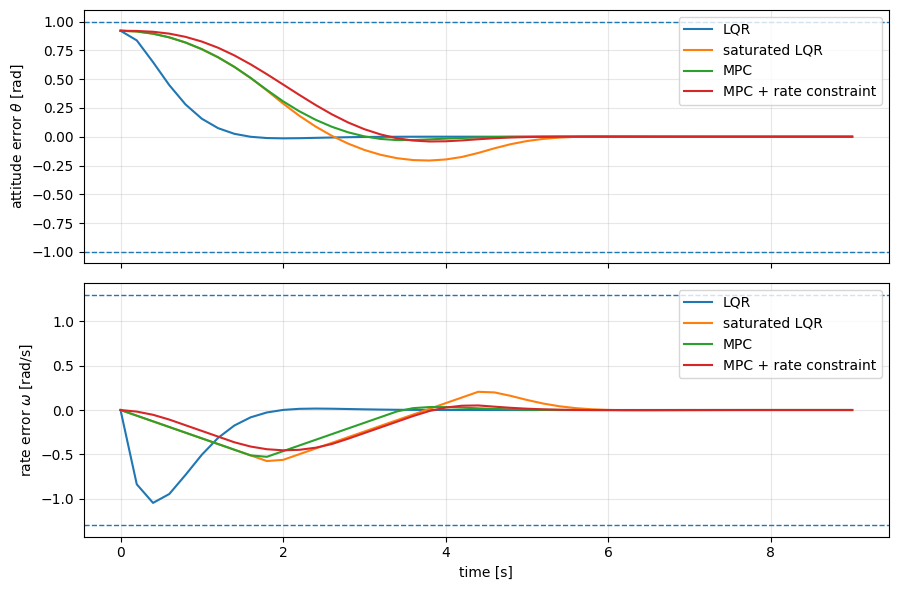

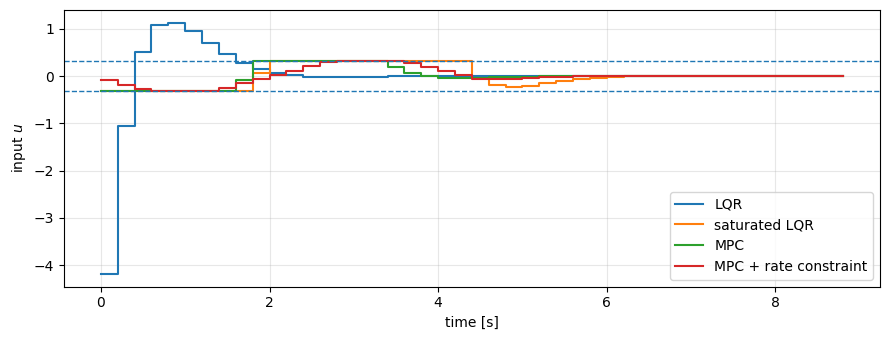

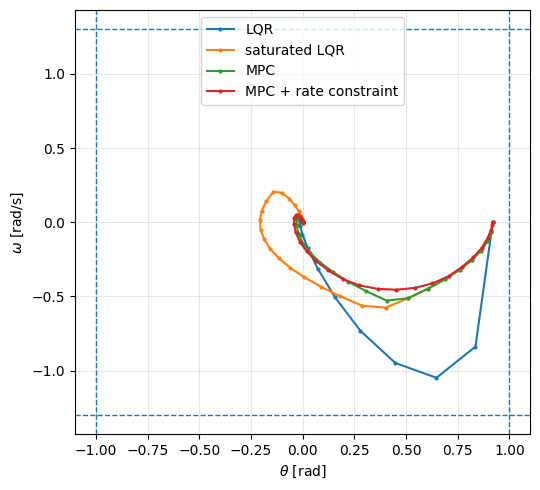

In [8]:
time = Ts * np.arange(steps + 1)
time_u = Ts * np.arange(steps)

plot_attitude_time_histories(time, results, theta_max, omega_max)
plot_attitude_inputs(time_u, results, u_max)
plot_attitude_phase(results, theta_max, omega_max)

## 7. Extension: soft angle constraint

For a soft constraint, the state bound is relaxed by a slack variable. The cost penalizes the slack:

$$
\theta_j \le \theta_{\max}+\epsilon_j,
\qquad
-\theta_{\max}-\epsilon_j \le \theta_j,
\qquad
\epsilon_j\ge 0.
$$

$$
J_{\mathrm{soft}} = J + \rho\sum_j \epsilon_j^2 .
$$

This is a practical feasibility mechanism, not a license to ignore safety-critical constraints.

The session version starts with a modest slack penalty so the tradeoff is easy to see. Then we can increase the penalty live and watch the tolerated violation shrink.

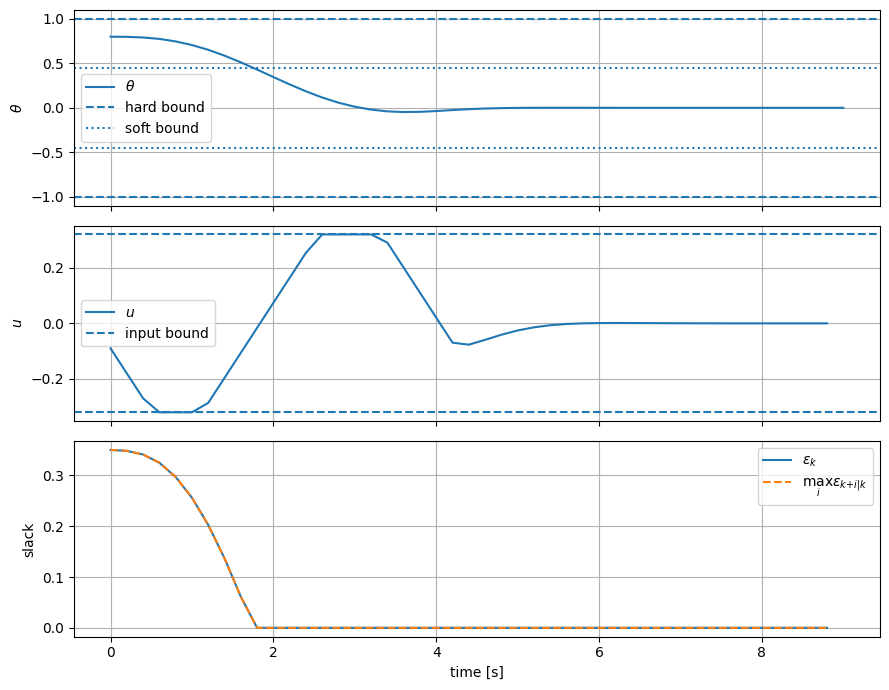

solver failures: 0
maximum current slack: 0.3500
maximum predicted slack: 0.3500
final state: theta = -0.0000, omega = 0.0000


In [9]:
x0_soft = np.array([0.80, 0.0])
theta_soft_max = 0.45

# SESSION POINT:
# First run: the soft constraint is active, but the slack penalty is still modest.
# Live change: set slack_penalty = 20_000.0 and rerun this section.
slack_penalty = 200.0
soft_rate_limit = Delta_u_max

x_soft = np.zeros((steps + 1, nx))
u_soft = np.zeros(steps)
slack_now = np.zeros(steps)
slack_pred_max = np.zeros(steps)
status_soft = []
solver_failures_soft = 0

x_soft[0] = x0_soft
u_previous = 0.0

for k in range(steps):
    result = solve_attitude_mpc(
        x_soft[k],
        u_previous=u_previous,
        rate_limit=soft_rate_limit,
        enforce_state_bounds=True,
        soften_angle=True,
        theta_soft_max=theta_soft_max,
        slack_penalty=slack_penalty,
    )

    u_k = result["u0"]
    status_soft.append(result["status"])

    if not result["success"]:
        solver_failures_soft += 1

    x_soft[k + 1] = A @ x_soft[k] + B.flatten() * u_k
    u_soft[k] = u_k
    u_previous = u_k

    slack_now[k] = result["slack"][0]
    slack_pred_max[k] = np.max(result["slack"])


# ------------------------------------------------------------------------------
# Plotting and summary for soft-constrained run
# ------------------------------------------------------------------------------

time = Ts * np.arange(steps + 1)
time_u = Ts * np.arange(steps)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].plot(time, x_soft[:, 0], label=r"$\theta$")
axes[0].axhline(theta_max, linestyle="--", label="hard bound")
axes[0].axhline(-theta_max, linestyle="--")
axes[0].axhline(theta_soft_max, linestyle=":", label="soft bound")
axes[0].axhline(-theta_soft_max, linestyle=":")
axes[0].set_ylabel(r"$\theta$")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(time_u, u_soft, label=r"$u$")
axes[1].axhline(u_max, linestyle="--", label="input bound")
axes[1].axhline(-u_max, linestyle="--")
axes[1].set_ylabel(r"$u$")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(time_u, slack_now, label=r"$\epsilon_k$")
axes[2].plot(time_u, slack_pred_max, linestyle="--", label=r"$\max_i \epsilon_{k+i|k}$")
axes[2].set_ylabel("slack")
axes[2].set_xlabel("time [s]")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"solver failures: {solver_failures_soft}")
print(f"maximum current slack: {np.nanmax(slack_now):.4f}")
print(f"maximum predicted slack: {np.nanmax(slack_pred_max):.4f}")
print(f"final state: theta = {x_soft[-1, 0]:.4f}, omega = {x_soft[-1, 1]:.4f}")